# GSM8K - Llama 3.1-8B-Instruct

**Tinker RL Project — PES University MTech Capstone (Group 6)**

| Field | Value |
|-------|-------|
| **Model** | `meta-llama/Llama-3.1-8B-Instruct` |
| **Parameters** | 8B |
| **Benchmark** | GSM8K (Grade School Math) |
| **Method** | GRPO (Group Relative Policy Optimization) + LoRA rank 32 |
| **Training API** | Tinker (Thinking Machines) — cloud GPU training |
| **Environment** | Atropos (NousResearch) — RL rollout framework |
| **Status** | Complete |
| **Tinker URI** | `tinker://9f53109d-.../sampler_weights/step_50` |


## Experiment Description

This experiment trains Llama 3.1-8B-Instruct on GSM8K — a cross-family comparison with Qwen3-8B.

**Key findings:**
- Started at ~79% accuracy — much higher baseline because this is an **instruct** model (already fine-tuned for following instructions)
- Reached 100% by step 35, sustained through step 50
- Instruct models have a massive head start over base models for structured tasks
- GRPO still adds value: pushed from 79% → 100% consistently



## Training Configuration

In [1]:
# Training configuration (gsm8k_llama_8b.yaml)
config_yaml = """
# GSM8K GRPO - Llama 3.1-8B-Instruct (Scaling experiment)
# Experiment: GRPO scaling ladder - 8B parameter point (Llama family)
# Uses NousResearch mirror for tokenizer (meta-llama is gated)

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "NousResearch/Meta-Llama-3.1-8B-Instruct"
  use_wandb: false
  rollout_server_url: "http://localhost:8006"
  wandb_name: "gsm8k-llama3.1-8b-env"
  ensure_scores_are_not_same: false
  max_token_length: 512
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "NousResearch/Meta-Llama-3.1-8B-Instruct"
    base_url: "http://localhost:8007/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00004
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/gsm8k_llama8b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "gsm8k-scaling-ladder"
  wandb_run_name: "gsm8k-llama3.1-8b"
  tinker_model_name: "meta-llama/Llama-3.1-8B-Instruct"

slurm: false
testing: false"""
print(config_yaml)


# GSM8K GRPO - Llama 3.1-8B-Instruct (Scaling experiment)
# Experiment: GRPO scaling ladder - 8B parameter point (Llama family)
# Uses NousResearch mirror for tokenizer (meta-llama is gated)

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "NousResearch/Meta-Llama-3.1-8B-Instruct"
  use_wandb: false
  rollout_server_url: "http://localhost:8006"
  wandb_name: "gsm8k-llama3.1-8b-env"
  ensure_scores_are_not_same: false
  max_token_length: 512
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "NousResearch/Meta-Llama-3.1-8B-Instruct"
    base_url: "http://localhost:8007/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00004
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/gsm8k_llama8b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "gsm8k-scaling-ladder"
  wandb_run_name: "gsm8k-llama3.1-8b"
  tinker

## Training Results

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 5)

steps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
rewards = [0.7891, 0.5156, 0.8359, 0.7422, 0.7891, 0.7109, 0.6719, 0.8047, 0.9375, 0.6719, 0.8672, 0.8594, 0.7812, 0.9609, 0.9531, 0.9297, 0.9922, 0.9609, 0.8828, 0.9766, 0.9219, 0.7891, 0.9219, 0.9375, 0.8828, 0.9766, 0.9922, 0.9531, 0.7734, 0.9531, 0.9531, 0.9297, 0.9062, 0.9844, 0.6875, 1.0, 0.9062, 0.9609, 0.9922, 0.7031, 0.9766, 0.8828, 0.9141, 0.9844, 0.9688, 0.9141, 0.9375, 0.9844, 0.9062, 1.0]
losses = [-43.58011817932129, 1311.510540008545, 261.4664840698242, 629.364725112915, 227.48105812072754, 1526.5228958129883, 1524.5943145751953, 35.37972545623779, 92.25849533081055, 602.4450759887695, 296.77758598327637, 410.2160415649414, 1449.7286529541016, 2.2143211364746094, -27.82894229888916, 152.58141040802002, -22.735533714294434, 61.309898376464844, 44.988407135009766, 20.54397201538086, -70.40685844421387, 402.7129592895508, -89.9764633178711, 45.01400947570801, 536.0661888122559, 90.34098052978516, -19.567511558532715, 120.54977798461914, 864.3839263916016, -39.103153228759766, 63.94209671020508, 69.86183547973633, 397.04048919677734, 96.02847671508789, -26.294170379638672, 0.0, 327.2909698486328, 18.327991485595703, -8.336491584777832, 379.43480682373047, -45.540531158447266, 238.78243923187256, 365.39337158203125, 136.96374130249023, -24.795284271240234, 464.515784740448, 29.45180034637451, 12.778514862060547, 442.61823081970215, 0.0]

print(f"Total steps completed: {len(steps)}")
print(f"Initial reward: {rewards[0]:.4f}" if rewards else "No data")
print(f"Final reward: {rewards[-1]:.4f}" if rewards else "No data")
print(f"Peak reward: {max(rewards):.4f}" if rewards else "No data")
print(f"Mean reward (last 10): {sum(rewards[-10:])/len(rewards[-10:]):.4f}" if len(rewards) >= 10 else "")


Total steps completed: 50
Initial reward: 0.7891
Final reward: 1.0000
Peak reward: 1.0000
Mean reward (last 10): 0.9469


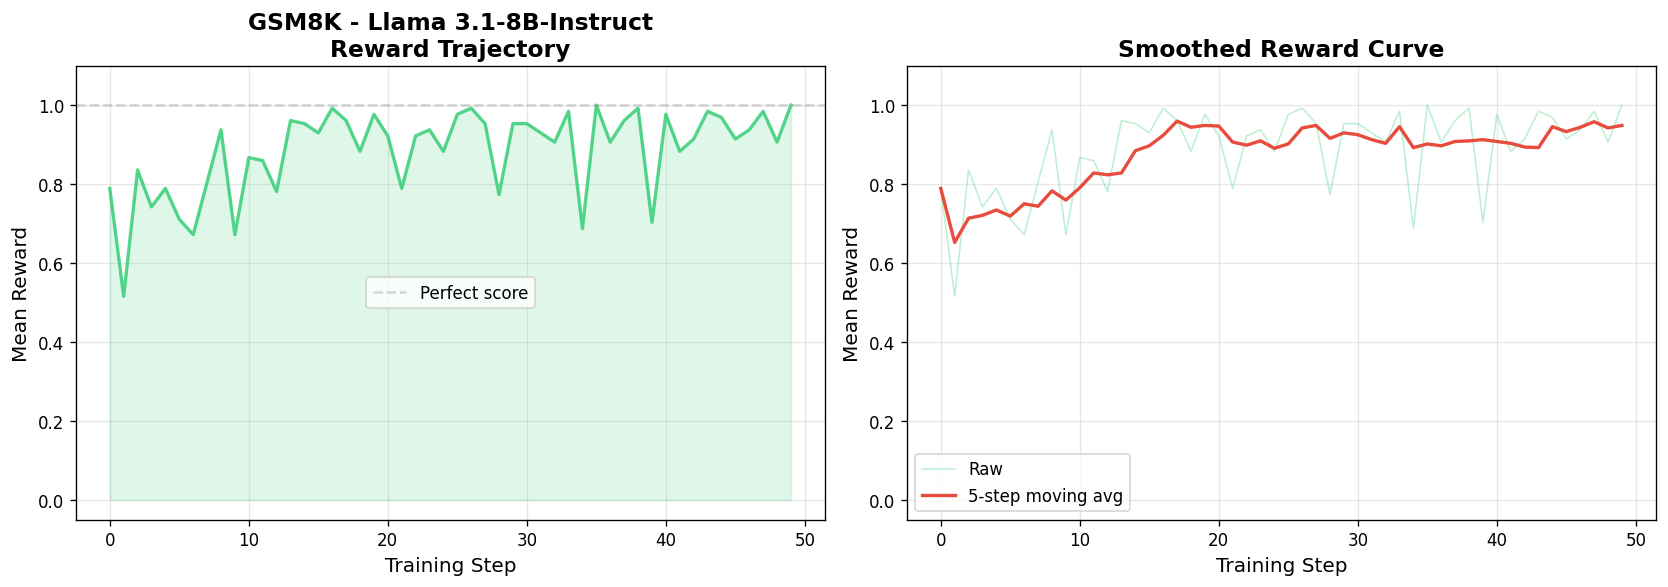

In [3]:
# Reward trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
ax1.plot(steps, rewards, color='#2ecc71', linewidth=2, alpha=0.8)
ax1.fill_between(steps, rewards, alpha=0.15, color='#2ecc71')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Mean Reward', fontsize=12)
ax1.set_title('GSM8K - Llama 3.1-8B-Instruct\nReward Trajectory', fontsize=14, fontweight='bold')
ax1.set_ylim(-0.05, 1.1)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='Perfect score')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Moving average
window = min(5, len(rewards))
if window > 1:
    moving_avg = [sum(rewards[max(0,i-window+1):i+1])/len(rewards[max(0,i-window+1):i+1]) for i in range(len(rewards))]
    ax2.plot(steps, rewards, color='#2ecc71', alpha=0.3, linewidth=1, label='Raw')
    ax2.plot(steps, moving_avg, color='#e74c3c', linewidth=2, label=f'{window}-step moving avg')
    ax2.set_xlabel('Training Step', fontsize=12)
    ax2.set_ylabel('Mean Reward', fontsize=12)
    ax2.set_title('Smoothed Reward Curve', fontsize=14, fontweight='bold')
    ax2.set_ylim(-0.05, 1.1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()


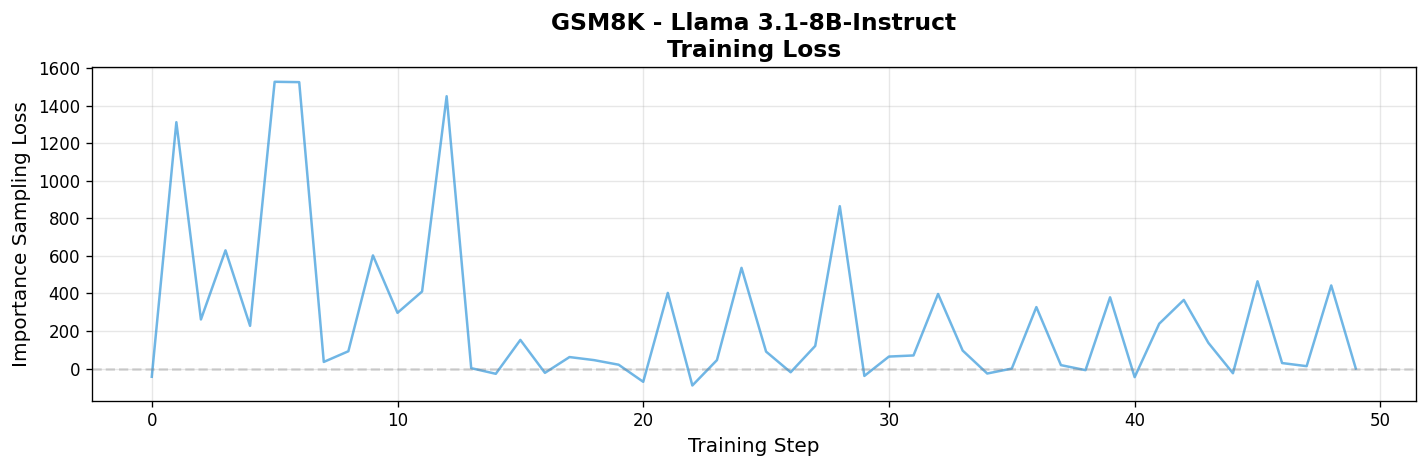

In [4]:
# Loss trajectory
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, losses, color='#3498db', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Importance Sampling Loss', fontsize=12)
ax.set_title('GSM8K - Llama 3.1-8B-Instruct\nTraining Loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Step-by-Step Data

In [5]:
import pandas as pd
df = pd.DataFrame({
    'Step': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
    'Reward': [0.7891, 0.5156, 0.8359, 0.7422, 0.7891, 0.7109, 0.6719, 0.8047, 0.9375, 0.6719, 0.8672, 0.8594, 0.7812, 0.9609, 0.9531, 0.9297, 0.9922, 0.9609, 0.8828, 0.9766, 0.9219, 0.7891, 0.9219, 0.9375, 0.8828, 0.9766, 0.9922, 0.9531, 0.7734, 0.9531, 0.9531, 0.9297, 0.9062, 0.9844, 0.6875, 1.0, 0.9062, 0.9609, 0.9922, 0.7031, 0.9766, 0.8828, 0.9141, 0.9844, 0.9688, 0.9141, 0.9375, 0.9844, 0.9062, 1.0],
    'Loss': [-43.58011817932129, 1311.510540008545, 261.4664840698242, 629.364725112915, 227.48105812072754, 1526.5228958129883, 1524.5943145751953, 35.37972545623779, 92.25849533081055, 602.4450759887695, 296.77758598327637, 410.2160415649414, 1449.7286529541016, 2.2143211364746094, -27.82894229888916, 152.58141040802002, -22.735533714294434, 61.309898376464844, 44.988407135009766, 20.54397201538086, -70.40685844421387, 402.7129592895508, -89.9764633178711, 45.01400947570801, 536.0661888122559, 90.34098052978516, -19.567511558532715, 120.54977798461914, 864.3839263916016, -39.103153228759766, 63.94209671020508, 69.86183547973633, 397.04048919677734, 96.02847671508789, -26.294170379638672, 0.0, 327.2909698486328, 18.327991485595703, -8.336491584777832, 379.43480682373047, -45.540531158447266, 238.78243923187256, 365.39337158203125, 136.96374130249023, -24.795284271240234, 464.515784740448, 29.45180034637451, 12.778514862060547, 442.61823081970215, 0.0],
})
df['Reward_pct'] = (df['Reward'] * 100).round(2).astype(str) + '%'
print(df[['Step', 'Reward_pct', 'Loss']].to_string(index=False))


 Step Reward_pct        Loss
    0     78.91%  -43.580118
    1     51.56% 1311.510540
    2     83.59%  261.466484
    3     74.22%  629.364725
    4     78.91%  227.481058
    5     71.09% 1526.522896
    6     67.19% 1524.594315
    7     80.47%   35.379725
    8     93.75%   92.258495
    9     67.19%  602.445076
   10     86.72%  296.777586
   11     85.94%  410.216042
   12     78.12% 1449.728653
   13     96.09%    2.214321
   14     95.31%  -27.828942
   15     92.97%  152.581410
   16     99.22%  -22.735534
   17     96.09%   61.309898
   18     88.28%   44.988407
   19     97.66%   20.543972
   20     92.19%  -70.406858
   21     78.91%  402.712959
   22     92.19%  -89.976463
   23     93.75%   45.014009
   24     88.28%  536.066189
   25     97.66%   90.340981
   26     99.22%  -19.567512
   27     95.31%  120.549778
   28     77.34%  864.383926
   29     95.31%  -39.103153
   30     95.31%   63.942097
   31     92.97%   69.861835
   32     90.62%  397.040489
   33     98.4

## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    GRPO Training Pipeline                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌───────────────────┐  │
│  │  Atropos     │───▶│  Environment │───▶│  Tinker Trainer   │  │
│  │  (run-api)   │    │  (GSM8K/MATH)│    │  (GRPO + LoRA)   │  │
│  │  Coordinator │◀───│  Scoring     │◀───│  Cloud GPUs      │  │
│  └─────────────┘    └──────────────┘    └───────────────────┘  │
│        │                    │                      │            │
│        │              Rollouts with           LoRA weights      │
│        │              binary rewards         updated via        │
│        │              (0 or 1)            importance sampling    │
│        │                    │                      │            │
│        └────────────────────┴──────────────────────┘            │
│                      Data flow loop                             │
└─────────────────────────────────────────────────────────────────┘
```
